# Price Elasticity Analysis

## Objective

The objective of this notebook is to analyze how changes in product prices affect customer demand.

This analysis helps businesses:

- Understand customer price sensitivity.
- Optimize product pricing.
- Improve revenue.
- Support pricing decisions using data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/retail_price_feature_engineered.csv")

df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_3,ps3,fp3,lag_price,revenue,avg_comp_price,price_difference,price_ratio,freight_percentage,revenue_per_customer
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,45.95,4.0,15.100000,45.90,45.95,116.950000,-71.000000,0.392903,32.861806,0.806140
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,45.95,4.0,12.933333,45.95,137.85,114.950000,-69.000000,0.399739,28.146536,2.259836
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,45.95,4.0,14.840000,45.95,275.70,113.616667,-67.666667,0.404430,32.295974,2.241463
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,45.95,4.0,14.287500,45.95,183.80,111.786601,-65.836601,0.411051,31.093580,2.042222
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,45.95,4.0,15.100000,45.95,91.90,99.749570,-53.799570,0.460654,32.861806,1.701852


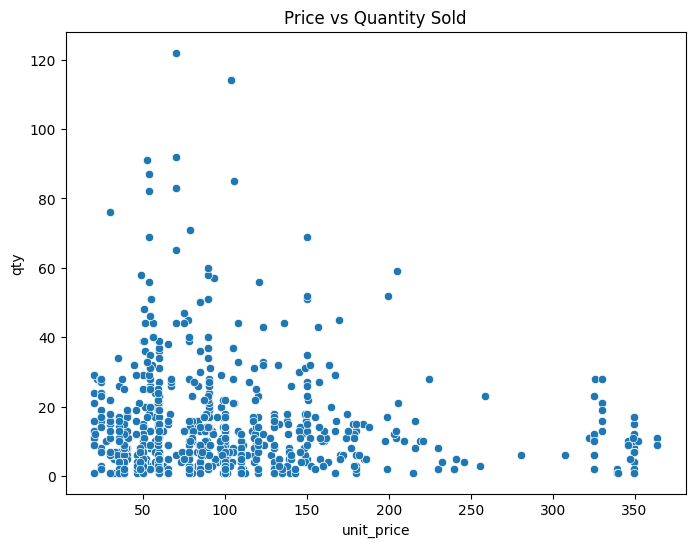

In [2]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="unit_price",
    y="qty"
)

plt.title("Price vs Quantity Sold")

plt.show()

In [3]:
correlation = df["unit_price"].corr(df["qty"])

print(correlation)

-0.10343211686728548


### Interpretation

The negative correlation between unit price and quantity sold indicates that customer demand generally decreases as prices increase.

This observation supports the economic principle of price elasticity of demand.

In [4]:
df["price_group"] = pd.cut(
    df["unit_price"],
    bins=5
)

In [5]:
price_demand = (
    df.groupby("price_group")["qty"]
      .mean()
)

price_demand

C:\Users\Admin\AppData\Local\Temp\ipykernel_16028\1093561262.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_group")["qty"]


price_group
(19.556, 88.72]     16.021407
(88.72, 157.54]     14.004115
(157.54, 226.36]    12.763636
(226.36, 295.18]     5.900000
(295.18, 364.0]      9.658537
Name: qty, dtype: float64

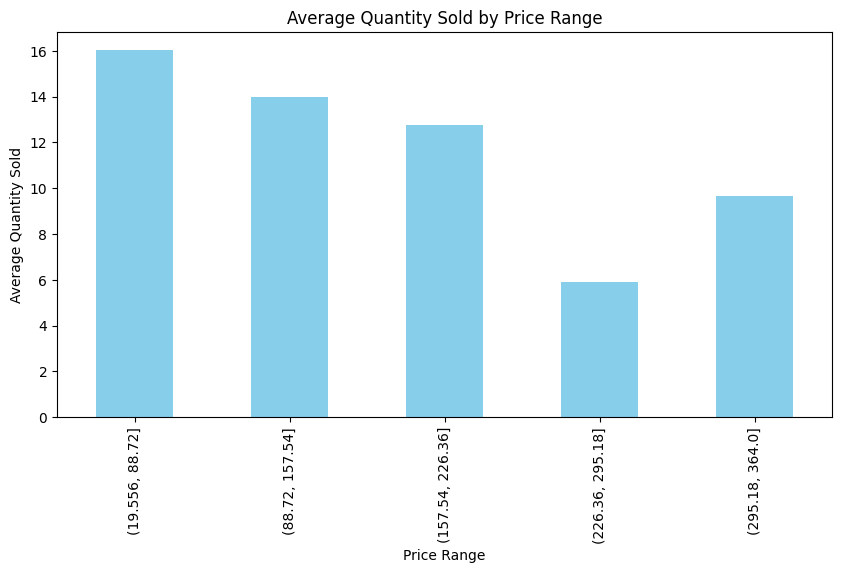

In [7]:
plt.figure(figsize=(10,5))

price_demand.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Average Quantity Sold by Price Range")

plt.xlabel("Price Range")

plt.ylabel("Average Quantity Sold")

plt.show()

In [8]:
df["revenue"] = (
    df["unit_price"] *
    df["qty"]
)

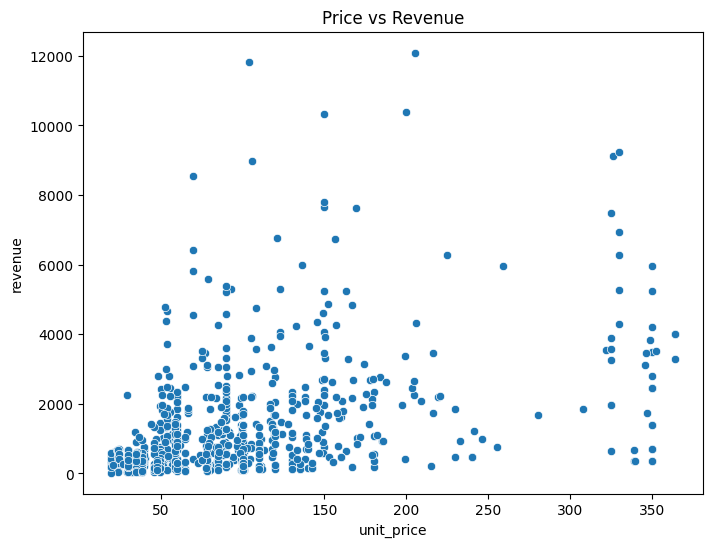

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="unit_price",
    y="revenue"
)

plt.title("Price vs Revenue")

plt.show()

## Business Recommendations

Based on the analysis:

- Avoid increasing prices for products with high price sensitivity.
- Monitor competitor pricing regularly.
- Focus promotional campaigns on products with declining demand.
- Optimize pricing using historical demand trends.
- Use predictive models to estimate demand before changing prices.

# Conclusion

This project explored the relationship between pricing and customer demand.

Key findings:

- Demand generally decreases as price increases.
- Decision Tree achieved the highest predictive accuracy.
- Competitor pricing influences product pricing decisions.
- Data-driven pricing strategies can improve revenue while maintaining customer demand.

In [10]:
df.to_csv("retail_price_final.csv", index=False)